# Generating a type split matrix from stock-per-type data

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib
from datetime import datetime

In [3]:
type_data = pd.read_excel("type_split_data_1981_2006.xlsx", skiprows = 2)

Test

In [4]:
print(type_data)

                                           Unnamed: 0          1981  \
0                     Stuehuse til landbrugsejendomme  1.561750e+05   
1                                          Parcelhuse  8.627730e+05   
2                        Række-, kæde- og dobbelthuse  1.572100e+05   
3                                        Etageboliger  8.209910e+05   
4                                                 Sum  1.997149e+06   
5                                      Stuehuse ratio  7.819897e-02   
6                                    Parcelhuse ratio  4.320023e-01   
7                                      Rekkehus ratio  7.871721e-02   
8                                  Etageboliger ratio  4.110815e-01   
9                                  Avg ratio stuehuse  6.247550e-02   
10                               Avg ratio parcelhuse  4.231135e-01   
11                                 Avg ratio rekkehus  1.180194e-01   
12                             Avg ratio etageboliger  3.963916e-01   
13    

In [5]:
# Get row 5 from column B-AA
ratio_stuehus = type_data.iloc[5, 1:27]
ratio_parcelhus = type_data.iloc[6, 1:27]
ratio_rekkehus = type_data.iloc[7, 1:27]
ratio_etage = type_data.iloc[8, 1:27]

print(ratio_etage)




1981    0.411081
1982    0.409713
1983    0.409677
1984    0.407506
1985    0.403746
1986    0.400859
1987    0.397217
1988    0.395562
1989     0.39405
1990       0.393
1991    0.392266
1992    0.392914
1993    0.392275
1994    0.392773
1995    0.393197
1996     0.39405
1997    0.394398
1998    0.393915
1999    0.393389
2000    0.392789
2001    0.392603
2002    0.392512
2003    0.392014
2004    0.390963
2005    0.392155
2006    0.391559
Name: 8, dtype: object


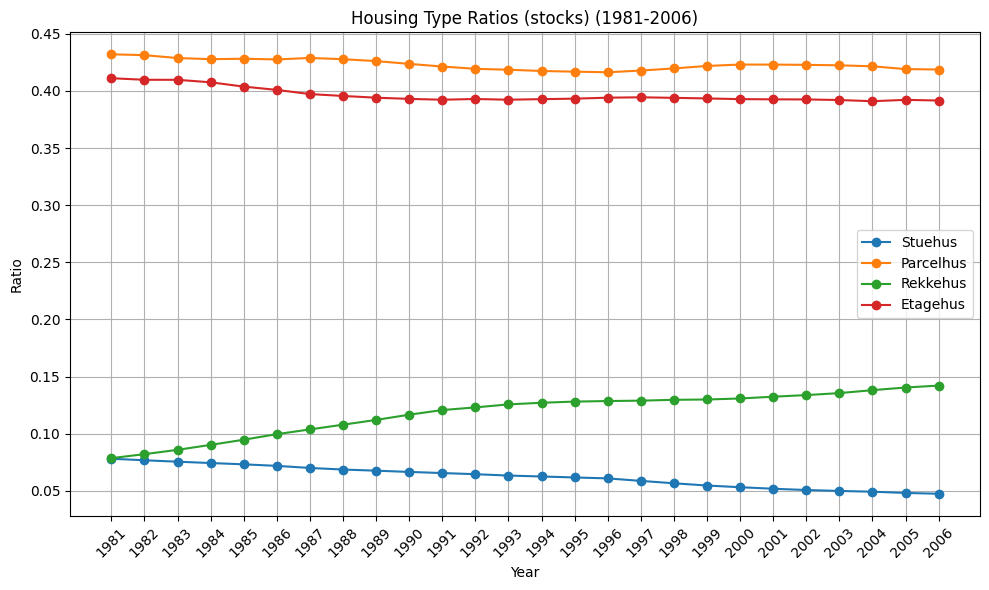

In [6]:
#Plot every ratio on the same graph
plt.figure(figsize=(10, 6))
plt.plot(ratio_stuehus.index, ratio_stuehus.values, label='Stuehus', marker='o')
plt.plot(ratio_parcelhus.index, ratio_parcelhus.values, label='Parcelhus', marker='o')
plt.plot(ratio_rekkehus.index, ratio_rekkehus.values, label='Rekkehus', marker='o')
plt.plot(ratio_etage.index, ratio_etage.values, label='Etagehus', marker='o')
plt.title('Housing Type Ratios (stocks) (1981-2006)')
plt.xlabel('Year')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
avg_ratio_stuehus = ratio_stuehus.mean()
avg_ratio_parcelhus = ratio_parcelhus.mean()
avg_ratio_rekkehus = ratio_rekkehus.mean()
avg_ratio_etage = ratio_etage.mean()


In [8]:
print(avg_ratio_stuehus.round(2))
print(avg_ratio_parcelhus.round(2))
print(avg_ratio_rekkehus.round(2))
print(avg_ratio_etage.round(2))


0.06
0.42
0.12
0.4


In [9]:
type_split_matrix_df = pd.DataFrame([{
    'Stuehus': avg_ratio_stuehus.round(2),
    'Parcelhus': avg_ratio_parcelhus.round(2),
    'Rekkehus': avg_ratio_rekkehus.round(2),
    'Etagehus': avg_ratio_etage.round(2)
}])

print(type_split_matrix_df)

   Stuehus  Parcelhus  Rekkehus  Etagehus
0     0.06       0.42      0.12       0.4


In [10]:
type_split_matrix_array = type_split_matrix_df.to_numpy()

print(type_split_matrix_array)

[[0.06 0.42 0.12 0.4 ]]


# Creating type-split matrix from inflow-data (MOST IMPORTANT)

In [11]:
inflow_type_data = pd.read_excel('inflows_ny_dwelling_98_25.xlsx', skiprows=2)

In [12]:
print(inflow_type_data)

                                           Unnamed: 0       Unnamed: 1  \
0                                           Nybyggeri  Boliger (antal)   
1                                                 NaN              NaN   
2                                                 NaN              NaN   
3                                                 NaN              NaN   
4                                                 NaN              NaN   
5                                                 NaN              NaN   
6                                                 NaN              NaN   
7                                                 NaN              NaN   
8                                                 NaN              NaN   
9                                                 NaN              NaN   
10                                                NaN              NaN   
11                                                NaN              NaN   
12                                    

In [13]:
ratio_stuehus_inflows = inflow_type_data.iloc[5, 2:31]
ratio_parcelhus_inflows = inflow_type_data.iloc[6, 2:31]
ratio_rekkehus_inflows = inflow_type_data.iloc[7, 2:31]
ratio_etage_inflows = inflow_type_data.iloc[8, 2:31]

print(ratio_etage_inflows)

# Create a DataFrame for the type split inflows, axis = 1
type_split_m_inflows_df = pd.DataFrame({
    'Year': inflow_type_data.columns[2:31].values,
    'Stuehus': ratio_stuehus_inflows.values,
    'Parcelhus': ratio_parcelhus_inflows.values,
    'Rekkehus': ratio_rekkehus_inflows.values,
    'Etagehus': ratio_etage_inflows.values
})

#print(type_split_m_inflows_df)

#skip first row of data frame
type_split_m_inflows_df_ = type_split_m_inflows_df.iloc[1:]
#print(type_split_m_inflows_df_)

Unnamed: 2    Ratio Etage
1998             0.299153
1999             0.212624
2000              0.29136
2001             0.293079
2002             0.330387
2003             0.316871
2004             0.350576
2005             0.349033
2006             0.344841
2007             0.383365
2008             0.285447
2009             0.320415
2010             0.288736
2011             0.273273
2012             0.431326
2013             0.447245
2014             0.412556
2015             0.355103
2016             0.464702
2017             0.520803
2018             0.551609
2019             0.588436
2020             0.602555
2021              0.53408
2022             0.540332
2023              0.57695
2024             0.573131
2025             0.542302
Name: 8, dtype: object


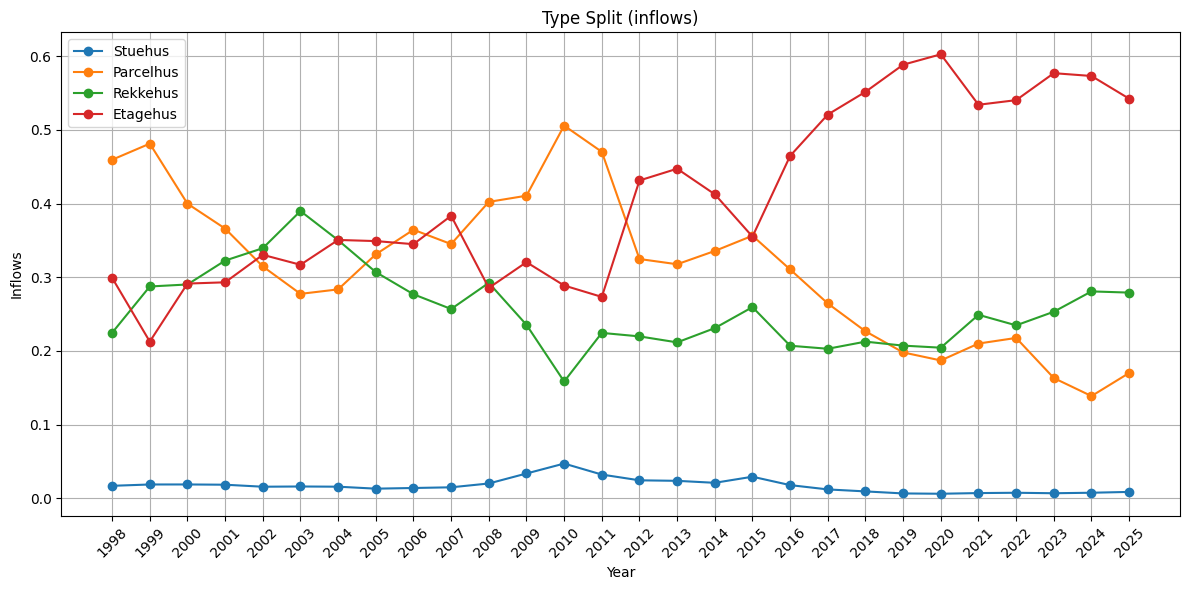

In [14]:
# plot type_split_m_inflows_df_
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# ensure Year is numeric (extract four-digit year if the header is e.g. "1981" or "1981-01")
type_split_m_inflows_df_['Year'] = type_split_m_inflows_df_['Year'].astype(str).str.extract(r'(\d{4})')[0].astype(int)

# convert ratio columns to numeric and handle non-numeric values
for col in type_split_m_inflows_df_.columns[1:]:
    type_split_m_inflows_df_[col] = pd.to_numeric(type_split_m_inflows_df_[col], errors='coerce')

# plot
for column in type_split_m_inflows_df_.columns[1:]:
    plt.plot(type_split_m_inflows_df_['Year'], type_split_m_inflows_df_[column], marker='o', label=column)

plt.title('Type Split (inflows)')
plt.xlabel('Year')
plt.ylabel('Inflows')
plt.xticks(type_split_m_inflows_df_['Year'], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
inflow_1943_2025 = pd.read_excel('Samlet_byggaktivitet_42-25.xlsx', skiprows=2)

#print(inflow_1943_2025.head())

print(inflow_1943_2025.iloc[:,1]) #set this as index
inflow_1943_2025.set_index(inflow_1943_2025.iloc[:,1], inplace=True)

#set index name
inflow_1943_2025.index.name = 'Type'

print(inflow_1943_2025)


0      Fritliggende enfamiliehuse
1    Række-, kæde- og dobbelthuse
2                    Etageboliger
3                             Tot
4                 Ratio_parcelhus
5                 Ratio_rekkehus 
6                     Ratio_etage
Name: Unnamed: 1, dtype: str
                                                                     Unnamed: 0  \
Type                                                                              
Fritliggende enfamiliehuse                           Fuldført boliger (1917 - )   
Række-, kæde- og dobbelthuse                                                NaN   
Etageboliger                                                                NaN   
Tot                                                                         NaN   
Ratio_parcelhus               De historiske serier er dokumenteret i et nota...   
Ratio_rekkehus                                                              NaN   
Ratio_etage                                                          

In [35]:
ratio_parcel = inflow_1943_2025.loc['Ratio_parcelhus', :]
#print(ratio_parcel)

#print(inflow_1943_2025.index.tolist())

ratio_rekke = inflow_1943_2025.loc['Ratio_rekkehus ', :]
#print(ratio_rekke)

#give years index a name in ratio_parcel
ratio_parcel.index.name = 'Year'
#print(ratio_parcel)
ratio_rekke.index.name = 'Year'
print(ratio_rekke)

ratio_etage = inflow_1943_2025.loc['Ratio_etage', :]
print(ratio_etage)

Year
Unnamed: 0                NaN
Unnamed: 1    Ratio_rekkehus 
1943                 0.087972
1944                 0.112588
1945                 0.086328
                   ...       
2021                 0.237835
2022                 0.218886
2023                 0.242179
2024                 0.267519
2025                  0.26648
Name: Ratio_rekkehus , Length: 85, dtype: object
Unnamed: 0            NaN
Unnamed: 1    Ratio_etage
1943              0.64724
1944             0.641566
1945             0.645254
                 ...     
2021             0.554293
2022             0.568417
2023             0.592487
2024             0.590132
2025             0.558902
Name: Ratio_etage, Length: 85, dtype: object


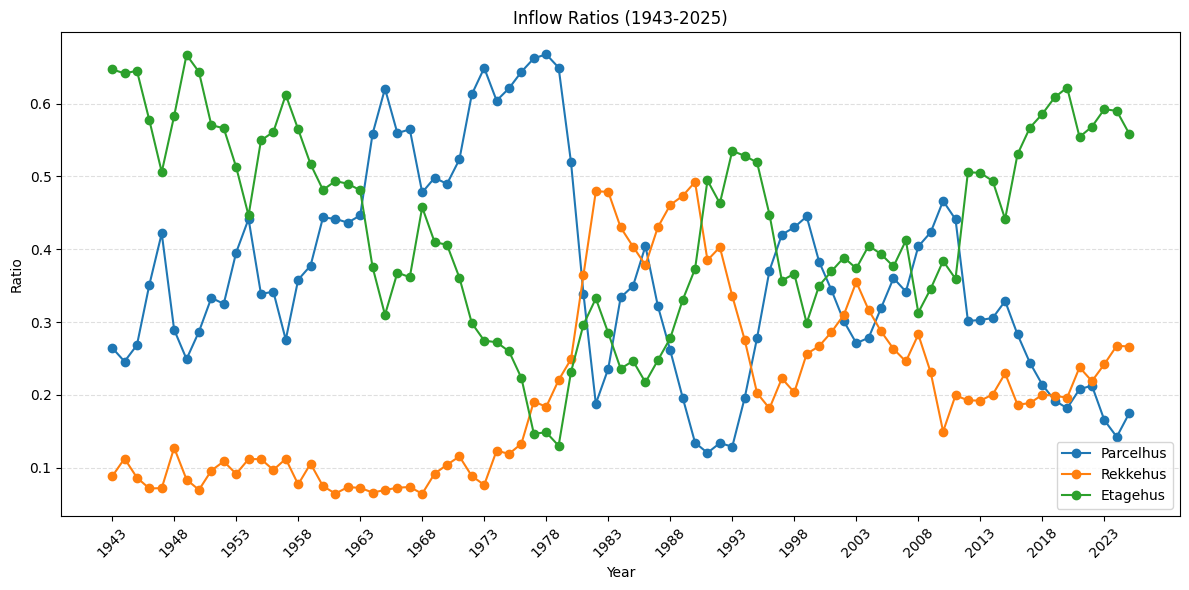

In [43]:
# Create a DataFrame for the type split inflows, axis = 1
type_split_m_inflows_df_1943_2025 = pd.DataFrame({
    'Year': ratio_parcel.index.values,
    'Parcelhus': ratio_parcel.values,
    'Rekkehus': ratio_rekke.values,
    'Etagehus': ratio_etage.values
})
#Skip row 0
type_split_m_inflows_df_1943_2025 = type_split_m_inflows_df_1943_2025.iloc[2:]
type_split_m_inflows_df_1943_2025.head()

# Plot the data
# Year skip 5
# Less grid
years = range(1943, 2026)

plt.figure(figsize=(12, 6))
plt.plot(years, type_split_m_inflows_df_1943_2025['Parcelhus'], label='Parcelhus', marker='o')
plt.plot(years, type_split_m_inflows_df_1943_2025['Rekkehus'], label='Rekkehus', marker='o')
plt.plot(years, type_split_m_inflows_df_1943_2025['Etagehus'], label='Etagehus', marker='o')
plt.title('Inflow Ratios (1943-2025)')
plt.xlabel('Year')
plt.ylabel('Ratio')
plt.legend()

plt.xticks(range(1943, 2026, 5), rotation=45)
plt.grid(axis='y', which='major', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [48]:
array_type_split_1943_2025 = type_split_m_inflows_df_1943_2025.iloc[:,1:].to_numpy()
print(array_type_split_1943_2025)




[[np.float64(0.26478739409296065) np.float64(0.08797212764272706)
  np.float64(0.6472404782643123)]
 [np.float64(0.2458458296182216) np.float64(0.11258814946907676)
  np.float64(0.6415660209127017)]
 [np.float64(0.2684179104477612) np.float64(0.08632835820895522)
  np.float64(0.6452537313432836)]
 [np.float64(0.3511911960333777) np.float64(0.07147176200266053)
  np.float64(0.5773370419639617)]
 [np.float64(0.4219494126362578) np.float64(0.0719652873319928)
  np.float64(0.5060853000317493)]
 [np.float64(0.2894973646998329) np.float64(0.12739426661524617)
  np.float64(0.5831083686849209)]
 [np.float64(0.24917931883463273) np.float64(0.08370947886746)
  np.float64(0.6671112022979072)]
 [np.float64(0.2868561812608931) np.float64(0.06953542881182763)
  np.float64(0.6436083899272793)]
 [np.float64(0.3333333333333333) np.float64(0.0961261727968687)
  np.float64(0.570540493869798)]
 [np.float64(0.32508515971463464) np.float64(0.10861880583585064)
  np.float64(0.5662960344495147)]
 [np.float64(